# Quality Control (QC), Doublet Detection (Scrublet), Filtering

- Scrublet per biopsy, top ~10% HVGs, expected_doublet_rate=0.10, remove cells with doublet_score > 0.25
- remove top 1% of cells by UMI count PER BIOPSY (presumed doublets)
- keep pct mito UMI < 10%
- keep n_genes > 100
- remove genes detected in zero retained cells (required for scran)


## Packages and paths

In [1]:
# Core scverse libraries
from __future__ import annotations
import logging

# Main
import anndata as ad 
import scanpy as sc
import pandas as pd
import numpy as np 
import scipy.sparse as sp
import os

# Plotting
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import colors
import seaborn as sns

# Scanpy setting: clean white background and high resolution figures
sc.set_figure_params(dpi=300, facecolor="white")
# Set the level of verbosity of scanpy to get more detailed info
sc.settings.verbosity = 3

try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    SCRIPT_DIR = os.getcwd()  # interactive fallback
PHASE_DIR = os.path.dirname(SCRIPT_DIR)  # 01_preprocessing/
FIG_DIR = os.path.join(PHASE_DIR, "figures", "01_2_qc_scrublet_filtering")  # figures/01_2_qc_scrublet_filtering/
os.makedirs(FIG_DIR, exist_ok=True)
sc.settings.figdir = FIG_DIR

# Tell Juptyter to show all outputs and not only the last one
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

!pip list 

Package                 Version       Build
----------------------- ------------- -----
absl-py                 2.5.0
aiohappyeyeballs        2.7.1
aiohttp                 3.14.1
aiosignal               1.4.0
anndata                 0.13.2
anndata2ri              2.0
annotated-types         0.7.0
annoy                   1.17.3
array-api-compat        1.15.0
asttokens               3.0.2
attrs                   26.1.0
backports.zstd          1.6.0
bbknn                   1.6.0
beautifulsoup4          4.15.0
Brotli                  1.2.0
cached-property         1.5.2
celltypist              1.7.1
certifi                 2026.7.22
cffi                    2.1.0
charset-normalizer      3.4.9
click                   8.4.2
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
Cython                  3.2.8
debugpy                 1.8.21
decorator               5.3.1
Deprecated              1.3.1
docrep                  0.3.2
donfig                  0.8.1.po

Setup the directory of the data. This is the path to the cluster data folder (outside the repo) or to the local data folder, like in this case.   
Raw and heavy intermediate objects live here; the repo holds only code.

In [2]:
try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    SCRIPT_DIR = os.getcwd()  # interactive fallback
PHASE_DIR = os.path.dirname(SCRIPT_DIR)  # 01_pre_processing/

DATA_DIR = os.environ.get("DATA_DIR", os.path.join(os.path.dirname(PHASE_DIR), "datasets"))
os.environ["DATA_DIR"] = DATA_DIR

# Input: concatenated object from phase 00_6
INPUT_H5AD = os.path.join(DATA_DIR, "all_samples_combined.h5ad")
print("Input :", INPUT_H5AD, "| exists:", os.path.exists(INPUT_H5AD))

Input : /home/albertoc/Desktop/QCB-Master-Thesis/datasets/all_samples_combined.h5ad | exists: True


## Quality Control

In [3]:
# Load the object (this is the only slow step; depends on file size)
adata = ad.read_h5ad(INPUT_H5AD)
adata

AnnData object with n_obs × n_vars = 743336 × 33538
    obs: 'sample', 'batch', 'cohort', 'treatment', 'fraction', 'dataset_origin', 'response'
    var: 'gene_ids', 'feature_types', 'genome'
    layers: 'counts', None (.X)

In [4]:
# Expects: `adata` = AnnData with raw counts in .X and .layers['counts'], per-biopsy grouping column 'sample', gene symbols as var_names.
# Produces: filtered `adata` with QC metrics and doublet flags in .obs, genes reduced to those detected in >=1 retained cell.

# Mitochondrial + ribosomal gene flags + QC metrics
# MT- : mitochondrial genes (human)
# RPS/RPL : cytoplasmic ribosomal protein genes (human)
adata.var['mt'] = adata.var_names.str.startswith('MT-')
adata.var['ribo'] = adata.var_names.str.startswith(('RPS', 'RPL'))

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=['mt', 'ribo'],
    inplace=True,
    percent_top=None,
    log1p=True,
)
# adds .obs: total_counts, n_genes_by_counts, pct_counts_mt, pct_counts_ribo
print("MT genes flagged  :", int(adata.var['mt'].sum()))
print("Ribo genes flagged:", int(adata.var['ribo'].sum()))
print(adata.obs[['total_counts', 'n_genes_by_counts',
                 'pct_counts_mt', 'pct_counts_ribo']].describe())
# Check new .obs
adata

MT genes flagged  : 13
Ribo genes flagged: 104
        total_counts  n_genes_by_counts  pct_counts_mt  pct_counts_ribo
count  743336.000000      743336.000000  743336.000000    743336.000000
mean     5070.950684        1462.062384       6.128273        17.781719
std      6724.031738        1149.579304      11.104650         9.611721
min         1.000000           1.000000       0.000000         0.000000
25%      1251.000000         633.000000       2.262130        10.638774
50%      2615.000000        1107.000000       3.618834        17.070707
75%      6206.000000        1989.000000       5.556497        23.951725
max    172371.000000       10564.000000     100.000000       100.000000


AnnData object with n_obs × n_vars = 743336 × 33538
    obs: 'sample', 'batch', 'cohort', 'treatment', 'fraction', 'dataset_origin', 'response', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'counts', None (.X)

In [5]:
vc = adata.obs['sample'].value_counts()
print("Cells per biopsy - summary:")
print(vc.describe())
print("\nSmallest 15 biopsies:")
print(vc.tail(15))

Cells per biopsy - summary:
count      149.000000
mean      4988.832215
std       4399.454296
min        109.000000
25%       1196.000000
50%       3950.000000
75%       7809.000000
max      19289.000000
Name: count, dtype: float64

Smallest 15 biopsies:
sample
P63_A_N    281
P45_C_N    268
P39_C_N    262
P63_C_N    243
P16_C_N    240
P64_A_N    219
P52_C_P    214
P63_A_P    189
P66_B_N    174
P45_C_P    169
P64_C_P    167
P66_C_N    162
P66_C_P    162
P64_A_P    131
P64_C_N    109
Name: count, dtype: int64


## Scrublet

In [6]:
# Run independently per biopsy (doublet scores depend on local composition).
# n_prin_comps is retried downward if a batch fails (too many components for the number of features).
# doublet_score : float (NaN where Scrublet failed on a batch)
# predicted_doublet : nullable boolean (pd.NA where Scrublet set no auto threshold)

BATCH_KEY = 'sample'
EXPECTED_DOUBLET_RATE = 0.10
DOUBLET_SCORE_CUTOFF = 0.25
RETRY_COMPS = [30, 20, 10, 5]   # try in order until one works

adata.obs['doublet_score'] = np.nan
adata.obs['predicted_doublet'] = pd.Series(pd.NA, index=adata.obs.index, dtype="boolean")

vc = adata.obs[BATCH_KEY].value_counts()
failed = []
degenerate = []

for s in vc.index:
    mask = (adata.obs[BATCH_KEY] == s).values
    sub = adata[mask].copy()

    success = False
    for nc in RETRY_COMPS:
        nc_eff = min(nc, sub.n_obs - 1)
        if nc_eff < 2:
            break
        try:
            sc.pp.scrublet(sub, expected_doublet_rate=EXPECTED_DOUBLET_RATE,
                           n_prin_comps=nc_eff, random_state=0)
        except Exception:
            continue   # too many components for this batch's features; retry lower

        adata.obs.loc[mask, 'doublet_score'] = sub.obs['doublet_score'].values
        adata.obs.loc[mask, 'predicted_doublet'] = sub.obs['predicted_doublet'].values

        pred = sub.obs['predicted_doublet'].values
        det_rate = float(np.nanmean(pred.astype('float'))) if pred.size else np.nan
        if not np.isnan(det_rate) and det_rate > 0.30:
            degenerate.append((s, sub.n_obs, det_rate))
        success = True
        break

    if not success:
        failed.append((s, sub.n_obs))

print("Doublet score summary:")
print(adata.obs['doublet_score'].describe())
print(f"NaN scores: {adata.obs['doublet_score'].isna().sum()}")
if failed:
    print(f"Batches failed ({len(failed)}): {[f'{s}(n={n})' for s, n in failed]}")
else:
    print("All batches processed.")
if degenerate:
    print(f"Degenerate fits (detected rate > 30%): {len(degenerate)}")
    for s, n, r in sorted(degenerate, key=lambda x: -x[2]):
        print(f"  {s} (n={n}): {100*r:.1f}%")

Running Scrublet
filtered out 12864 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:02)
extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
    Scrublet finished (0:01:56)
Running Scrublet
filtered out 14741 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finis

/tmp/ipykernel_11685/641595982.py:28: UserWarning: Some cells have zero counts
  sc.pp.scrublet(sub, expected_doublet_rate=EXPECTED_DOUBLET_RATE,
/tmp/ipykernel_11685/641595982.py:28: UserWarning: Some cells have zero counts
  sc.pp.scrublet(sub, expected_doublet_rate=EXPECTED_DOUBLET_RATE,
/home/albertoc/miniconda3/envs/benchmark-py-r/lib/python3.12/site-packages/scipy/sparse/_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


Running Scrublet
filtered out 15523 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.37
Detected doublet rate = 3.0%
Estimated detectable doublet fraction = 42.8%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 7.1%
    Scrublet finished (0:00:21)
Running Scrublet
filtered out 14811 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean

/tmp/ipykernel_11685/641595982.py:28: UserWarning: Some cells have zero counts
  sc.pp.scrublet(sub, expected_doublet_rate=EXPECTED_DOUBLET_RATE,


Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.40
Detected doublet rate = 0.1%
Estimated detectable doublet fraction = 7.6%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 1.6%
    Scrublet finished (0:00:01)
Running Scrublet
filtered out 20370 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.37
Detected doublet rate = 0.3%
Estimated detectable doublet fraction = 13.9%
Overall doublet rate:
	Expected

/tmp/ipykernel_11685/641595982.py:28: UserWarning: Some cells have zero counts
  sc.pp.scrublet(sub, expected_doublet_rate=EXPECTED_DOUBLET_RATE,


Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.27
Detected doublet rate = 1.2%
Estimated detectable doublet fraction = 13.6%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 8.6%
    Scrublet finished (0:00:00)
Running Scrublet
filtered out 18247 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.36
Detected doublet rate = 0.2%
Estimated detectable doublet fraction = 12.4%
Overall doublet rate:
	Expecte

### Save new AnnData object

In [7]:
# Save intermediate object (post-Scrublet) to avoid re-running Scrublet
sc.write(os.path.join(DATA_DIR, "all_samples_combined_scrublet"), adata, compression="gzip")
adata

AnnData object with n_obs × n_vars = 743336 × 33538
    obs: 'sample', 'batch', 'cohort', 'treatment', 'fraction', 'dataset_origin', 'response', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'counts', None (.X)

## Filtering

### Doublets

In [8]:
# Uses the fixed cutoff instead of Scrublet's per-batch automatic thresholds, which were unreliable on small/homogeneous biopsies.
# NaN scores -> False here (a cell Scrublet couldn't test is not flagged a doublet).
adata.obs['is_doublet_shiao'] = (adata.obs['doublet_score'] > DOUBLET_SCORE_CUTOFF).fillna(False)
print(f"Cells flagged as doublets (score > {DOUBLET_SCORE_CUTOFF}): "
      f"{int(adata.obs['is_doublet_shiao'].sum())} "
      f"({100*adata.obs['is_doublet_shiao'].mean():.2f}%)")

Cells flagged as doublets (score > 0.25): 37316 (5.02%)


### Top 1% by UMI count

In [9]:
# Top 1% by UMI count per biopsy flagged as presumed doublets
# Per-biopsy 99th percentile of total_counts; cells above it are the top 1%.
adata.obs['high_umi_doublet'] = False
for s in adata.obs[BATCH_KEY].unique():
    m = adata.obs[BATCH_KEY] == s
    thr = adata.obs.loc[m, 'total_counts'].quantile(0.99)
    adata.obs.loc[m & (adata.obs['total_counts'] > thr), 'high_umi_doublet'] = True
print(f"Cells flagged as high-UMI doublets (top 1% per biopsy): "
      f"{int(adata.obs['high_umi_doublet'].sum())} "
      f"({100*adata.obs['high_umi_doublet'].mean():.2f}%)")

Cells flagged as high-UMI doublets (top 1% per biopsy): 7499 (1.01%)


### Filtering Thresholds

In [10]:
# Final combined cell filter
# Keep iff: not a scrublet doublet AND not top-1% UMI AND pct_mt < 10 AND n_genes > 100
n_before = adata.n_obs
keep = (
    (~adata.obs['is_doublet_shiao']) &
    (~adata.obs['high_umi_doublet']) &
    (adata.obs['pct_counts_mt'] < 10) &
    (adata.obs['n_genes_by_counts'] > 100)
)
print("Cells removed by each criterion (marginal, not mutually exclusive):")
print(f"  scrublet doublet (>0.25) : {int(adata.obs['is_doublet_shiao'].sum())}")
print(f"  top 1% UMI per biopsy    : {int(adata.obs['high_umi_doublet'].sum())}")
print(f"  pct_mt >= 10             : {int((adata.obs['pct_counts_mt'] >= 10).sum())}")
print(f"  n_genes <= 100           : {int((adata.obs['n_genes_by_counts'] <= 100).sum())}")

adata = adata[keep].copy()
print(f"\nCells: {n_before:,} -> {adata.n_obs:,} ({100*adata.n_obs/n_before:.1f}% retained)")


Cells removed by each criterion (marginal, not mutually exclusive):
  scrublet doublet (>0.25) : 37316
  top 1% UMI per biopsy    : 7499
  pct_mt >= 10             : 71549
  n_genes <= 100           : 16997

Cells: 743,336 -> 619,692 (83.4% retained)


### Genes in at least three cell

In [12]:
# Placed after cell filtering; zero-count genes break scran's computeSumFactors
# .layers['counts'] is subset consistently with .X, so raw counts stay aligned
print('Total number of genes: {:d}'.format(adata.n_vars))
sc.pp.filter_genes(adata, min_cells=3)
print('Number of genes after zero-count filter: {:d}'.format(adata.n_vars))

Total number of genes: 30868
filtered out 1662 genes that are detected in less than 3 cells
Number of genes after zero-count filter: 29206


## Violin plots after filtering

In [12]:
# adata = sc.read_h5ad(os.path.join(DATA_DIR, "all_samples_combined_scrublet.h5ad"))

wrote violin_all_qc_after_filter_unintegrated.png


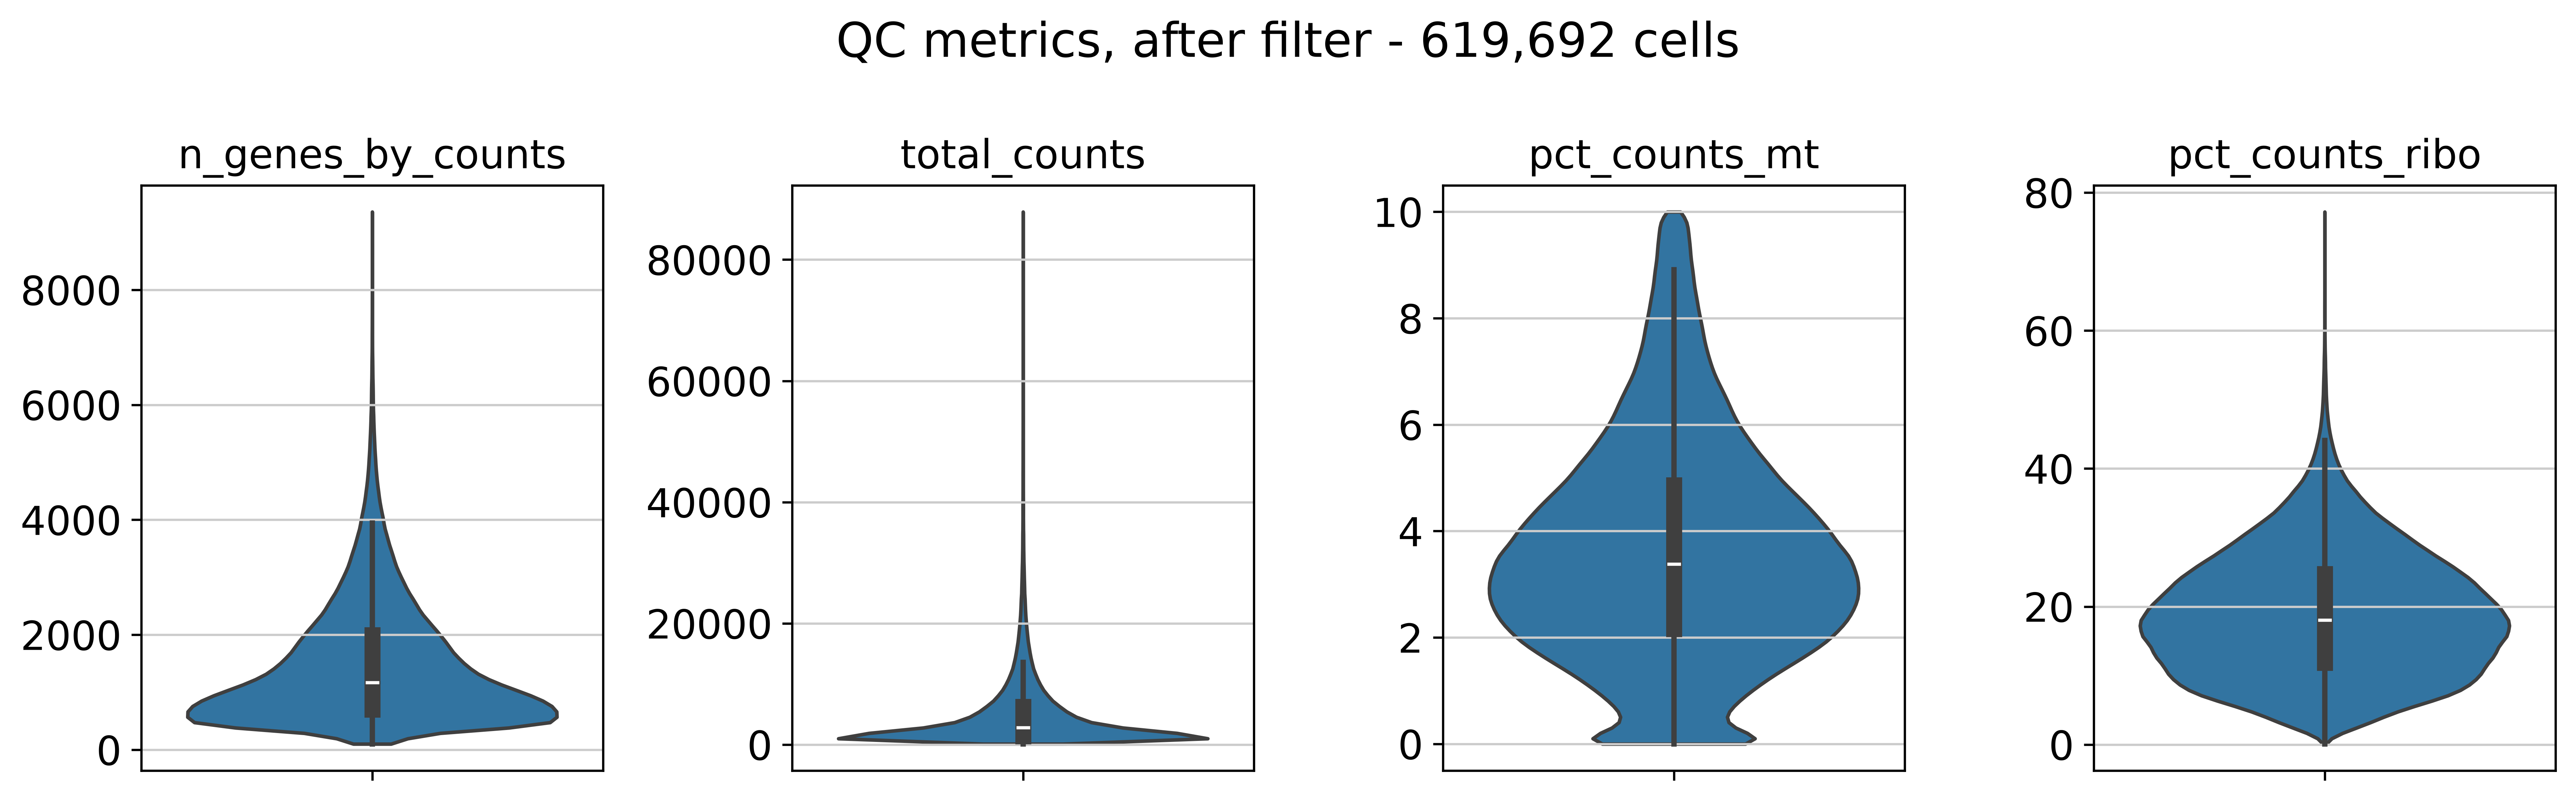

In [13]:
QC_METRICS = ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"]

def violin_qc_normal(adata, stage, suffix="all"):
    fig, axes = plt.subplots(
        1, len(QC_METRICS),
        figsize=(3.2 * len(QC_METRICS), 4)
    )

    for ax, metric in zip(axes, QC_METRICS):
        sns.violinplot(
            data=adata.obs,
            y=metric,
            ax=ax,
            color="tab:blue",
            cut=0
        )

        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title(metric)

    fig.suptitle(
        f"QC metrics, {stage.replace('_', ' ')} - {len(adata):,} cells"
    )
    fig.tight_layout()

    name = f"violin_{suffix}_qc_{stage}_unintegrated.png"
    fig.savefig(
        os.path.join(FIG_DIR, name),
        dpi=300,
        bbox_inches="tight"
    )

    print("wrote", name)
    plt.show()


violin_qc_normal(adata, "after_filter")

wrote violin_all_qc_after_filter_unintegrated_jitter.png


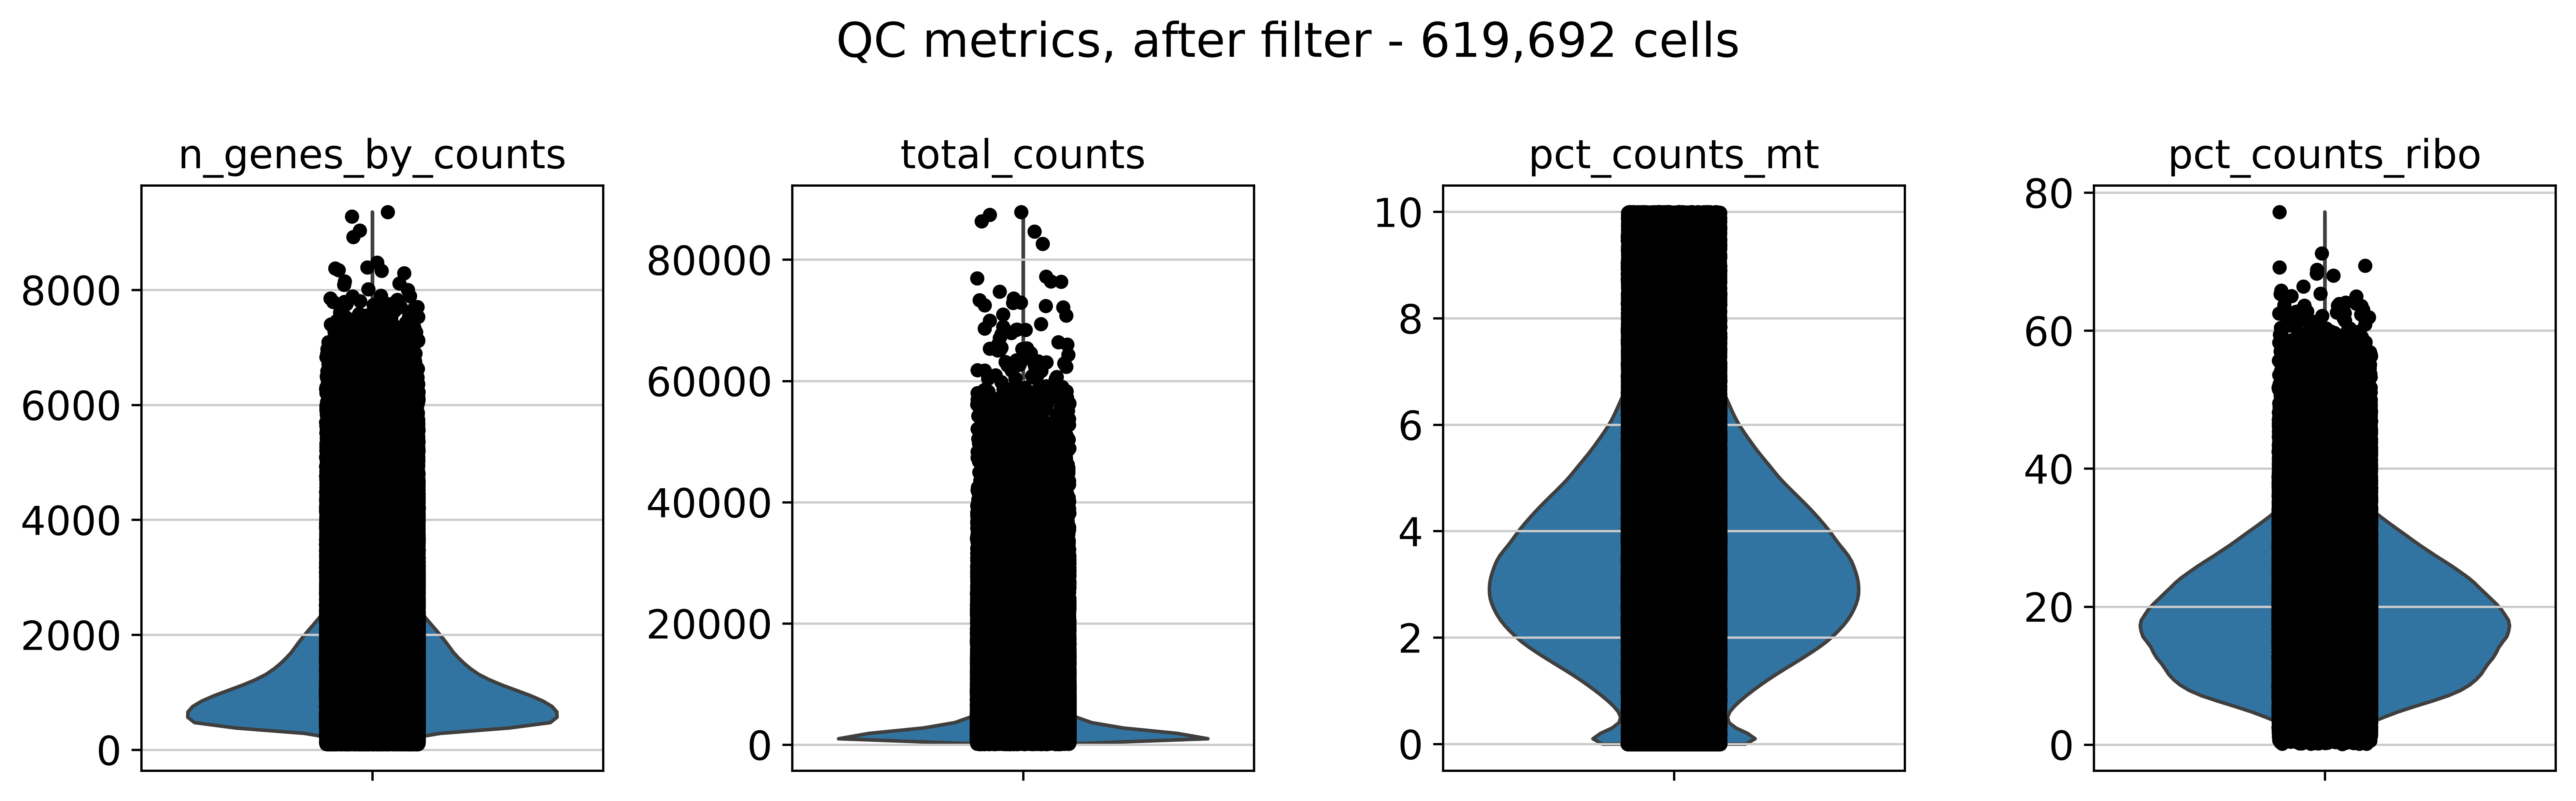

In [14]:
QC_METRICS = ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"]

def violin_qc_jitter(adata, stage, suffix="all"):
    fig, axes = plt.subplots(
        1, len(QC_METRICS),
        figsize=(3.2 * len(QC_METRICS), 4)
    )

    for ax, metric in zip(axes, QC_METRICS):
        sns.violinplot(
            data=adata.obs,
            y=metric,
            ax=ax,
            color="tab:blue",
            cut=0
        )

        sns.stripplot(
            data=adata.obs,
            y=metric,
            ax=ax,
            jitter=True,
            color="black"
        )

        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title(metric)

    fig.suptitle(
        f"QC metrics, {stage.replace('_', ' ')} - {len(adata):,} cells"
    )
    fig.tight_layout()

    name = f"violin_{suffix}_qc_{stage}_unintegrated_jitter.png"
    fig.savefig(
        os.path.join(FIG_DIR, name),
        dpi=300,
        bbox_inches="tight"
    )

    print("wrote", name)
    plt.show()


violin_qc_jitter(adata, "after_filter")

wrote violin_all_qc_after_filter_unintegrated_comparison.png


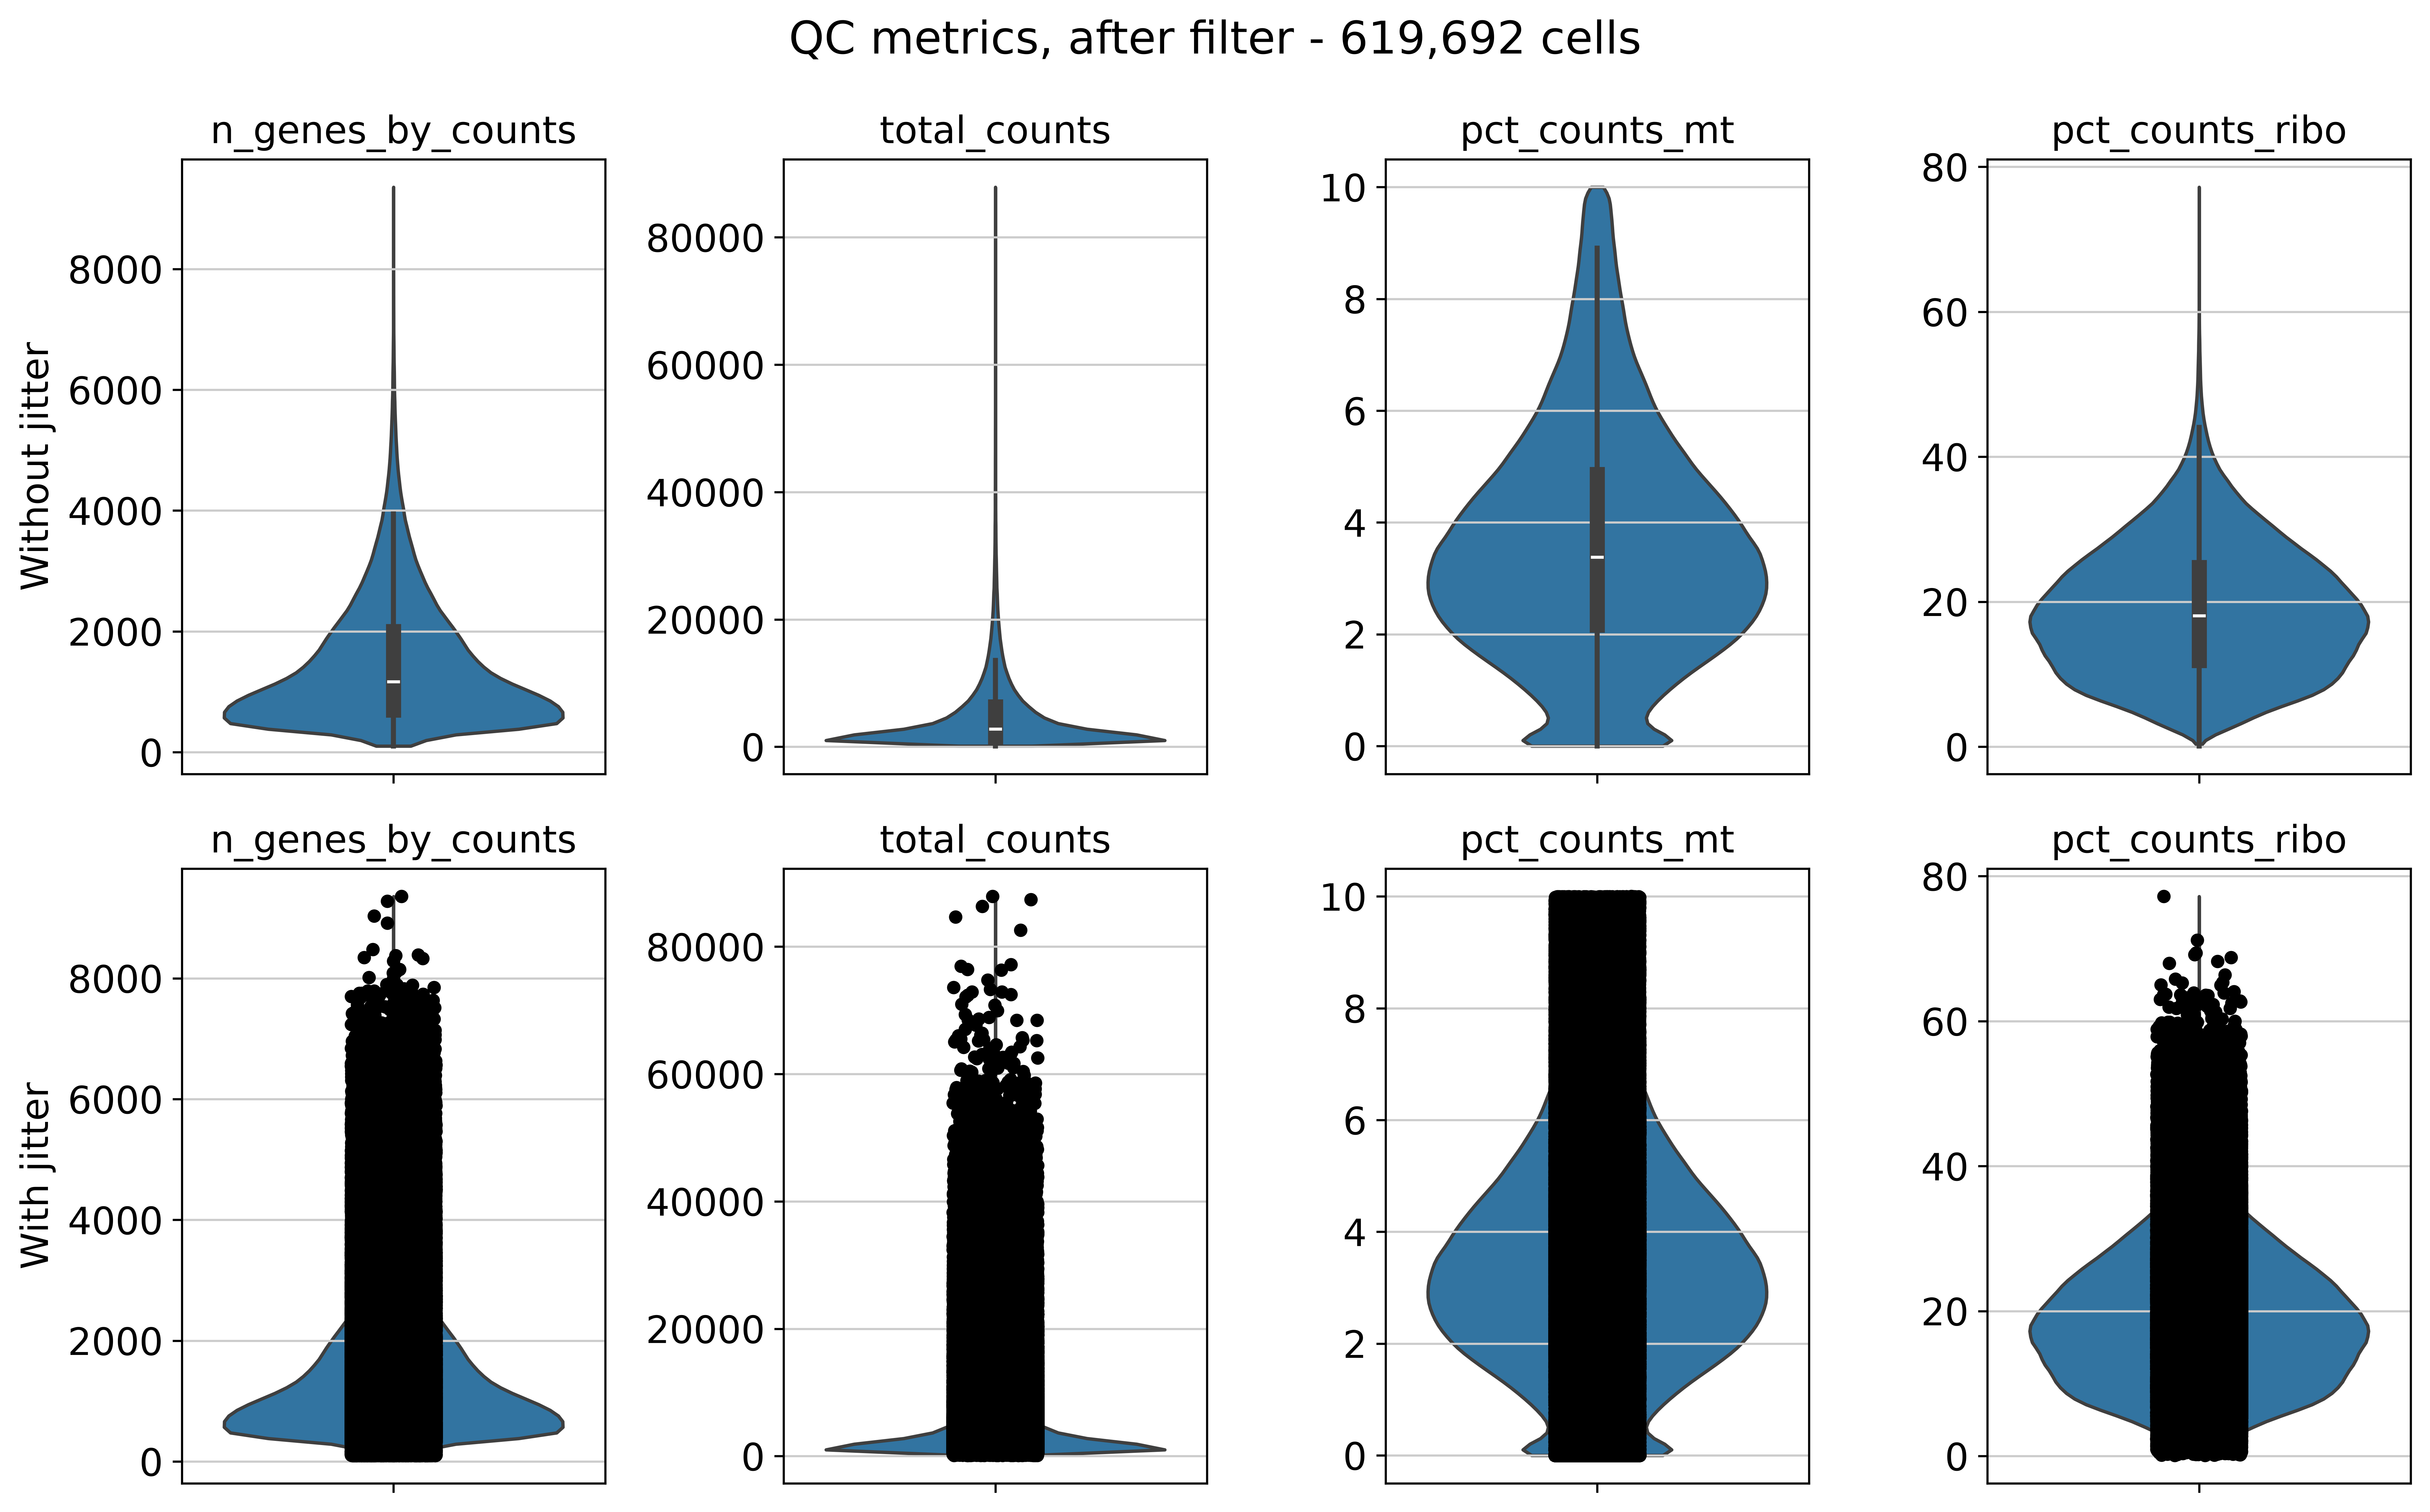

In [15]:
QC_METRICS = ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"]

def violin_qc(adata, stage, suffix="all"):
    fig, axes = plt.subplots(
        2, len(QC_METRICS),
        figsize=(3.2 * len(QC_METRICS), 8)
    )

    for col, metric in enumerate(QC_METRICS):

        # Normal violin
        sns.violinplot(
            data=adata.obs,
            y=metric,
            ax=axes[0, col],
            color="tab:blue",
            cut=0
        )

        # Violin + default jitter
        sns.violinplot(
            data=adata.obs,
            y=metric,
            ax=axes[1, col],
            color="tab:blue",
            cut=0
        )
        sns.stripplot(
            data=adata.obs,
            y=metric,
            ax=axes[1, col],
            jitter=True,
            color="black"
        )

        # Formatting
        axes[0, col].set_title(metric)
        axes[1, col].set_title(metric)

        for row in range(2):
            axes[row, col].set_xlabel("")
            axes[row, col].set_ylabel("")

    # Row labels
    axes[0, 0].set_ylabel("Without jitter")
    axes[1, 0].set_ylabel("With jitter")

    fig.suptitle(
        f"QC metrics, {stage.replace('_', ' ')} - {len(adata):,} cells"
    )

    fig.tight_layout()

    name = f"violin_{suffix}_qc_{stage}_unintegrated_comparison.png"
    fig.savefig(
        os.path.join(FIG_DIR, name),
        dpi=300,
        bbox_inches="tight"
    )

    print("wrote", name)
    plt.show()


violin_qc(adata, "after_filter")

/tmp/ipykernel_11685/1893766069.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_11685/1893766069.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_11685/1893766069.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_11685/1893766069.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_11685/1893766069.py:12: F

wrote violin_all_qc_after_filter_unintegrated_dataset_origin.png


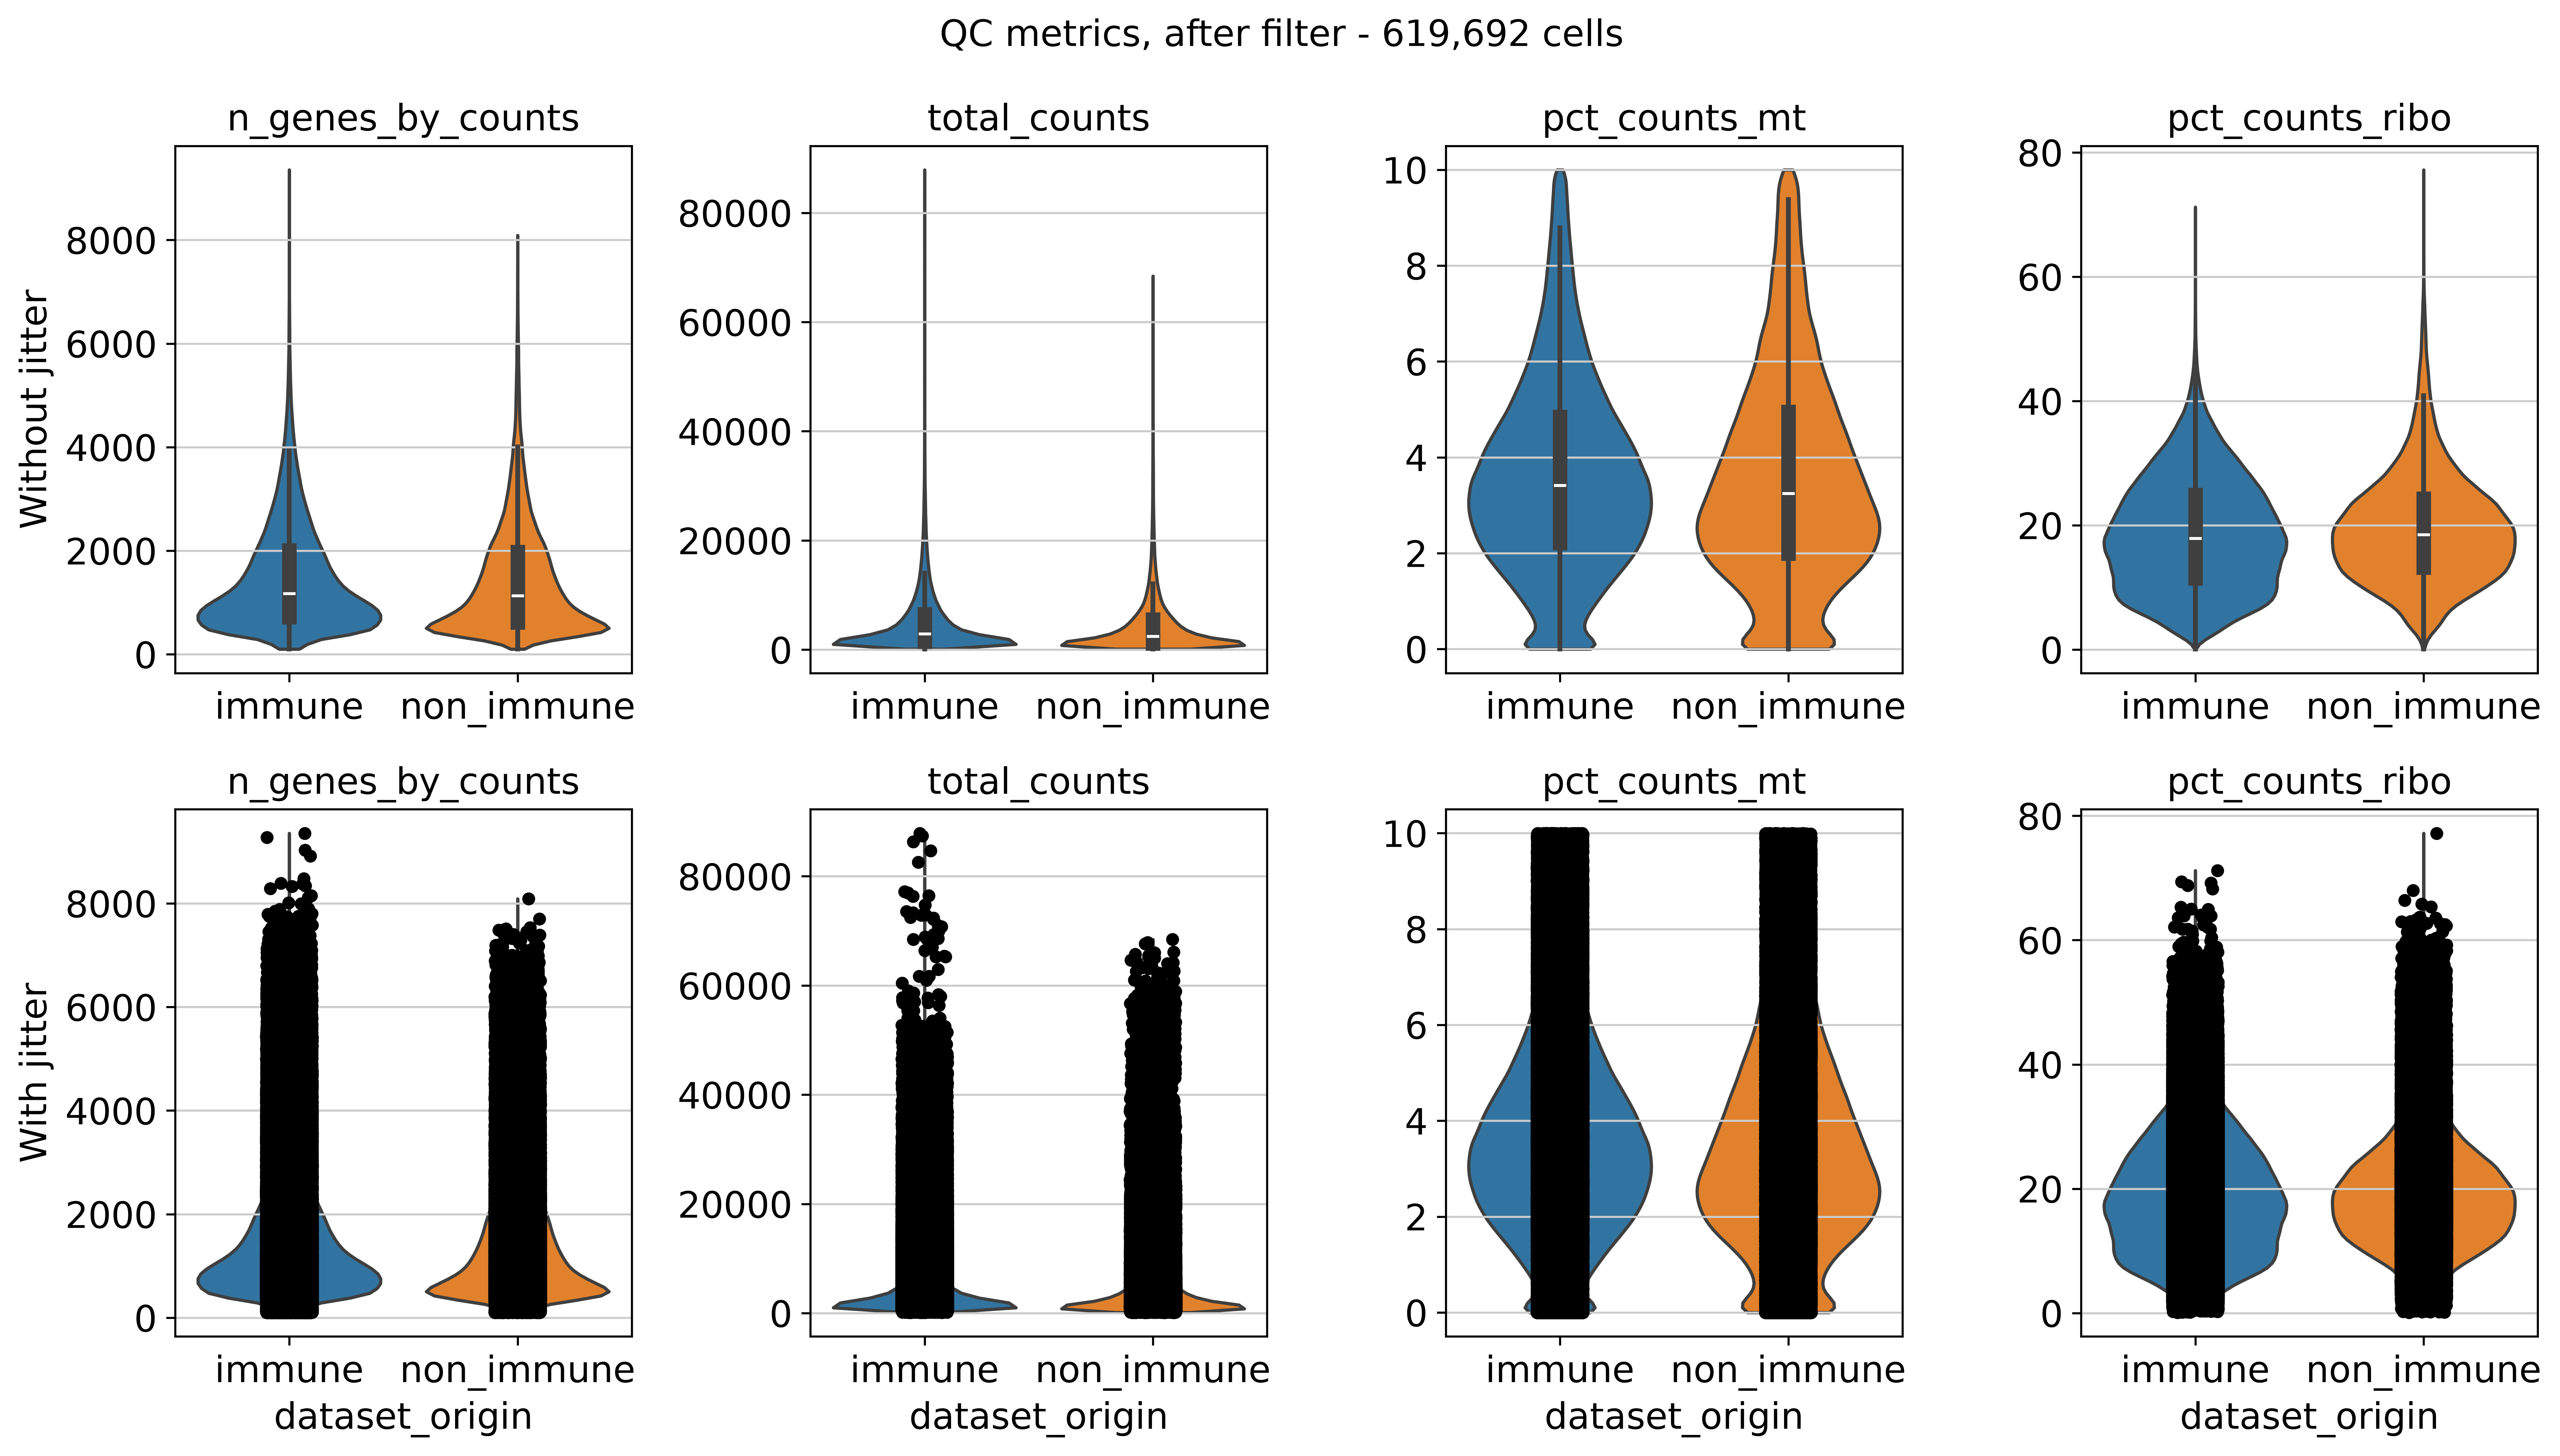

In [16]:
QC_METRICS = ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"]

def violin_qc_grouped(adata, stage, suffix="all"):

    fig, axes = plt.subplots(
        2, len(QC_METRICS),
        figsize=(3.5 * len(QC_METRICS), 8)
    )

    for col, metric in enumerate(QC_METRICS):

        sns.violinplot(
            data=adata.obs,
            x="dataset_origin",
            y=metric,
            ax=axes[0, col],
            cut=0,
            palette=["#1f77b4", "#ff7f0e"]
        )
        sns.violinplot(
            data=adata.obs,
            x="dataset_origin",
            y=metric,
            ax=axes[1, col],
            cut=0,
            palette=["#1f77b4", "#ff7f0e"]
        )

        sns.stripplot(
            data=adata.obs,
            x="dataset_origin",
            y=metric,
            ax=axes[1, col],
            jitter=True,
            color="black"
        )

        # Titles
        axes[0, col].set_title(metric)
        axes[1, col].set_title(metric)

        # Remove x-axis labels from top row
        axes[0, col].set_xlabel("")

        # Keep group labels on bottom row
        axes[1, col].set_xlabel("dataset_origin")

        # Remove y-axis labels
        axes[0, col].set_ylabel("")
        axes[1, col].set_ylabel("")

    # Row labels
    axes[0, 0].set_ylabel("Without jitter")
    axes[1, 0].set_ylabel("With jitter")

    # Overall title
    fig.suptitle(
        f"QC metrics, {stage.replace('_', ' ')} - {len(adata):,} cells",
        fontsize=14
    )

    fig.tight_layout()

    name = f"violin_{suffix}_qc_{stage}_unintegrated_dataset_origin.png"

    fig.savefig(
        os.path.join(FIG_DIR, name),
        dpi=300,
        bbox_inches="tight"
    )

    print("wrote", name)
    plt.show()


violin_qc_grouped(adata, "after_filter")

In [33]:
adata.obs["total_counts"].describe()
adata.obs["n_genes_by_counts"].describe()
adata.obs["pct_counts_mt"].describe()

count    619693.000000
mean       4915.481934
std        5633.125488
min         114.000000
25%        1408.000000
50%        2811.000000
75%        6267.000000
max       87877.000000
Name: total_counts, dtype: float64

count    619693.000000
mean       1477.962028
std        1043.470222
min         101.000000
25%         699.000000
50%        1169.000000
75%        1997.000000
max        9355.000000
Name: n_genes_by_counts, dtype: float64

count    619693.000000
mean          3.651310
std           2.098244
min           0.000000
25%           2.164591
50%           3.382648
75%           4.862433
max           9.998828
Name: pct_counts_mt, dtype: float64

/tmp/ipykernel_17830/3948966146.py:2: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt", title= "Shiao Scatter - mt", save="_percent_mito_total_counts_vs_n_genes_by_counts.png")


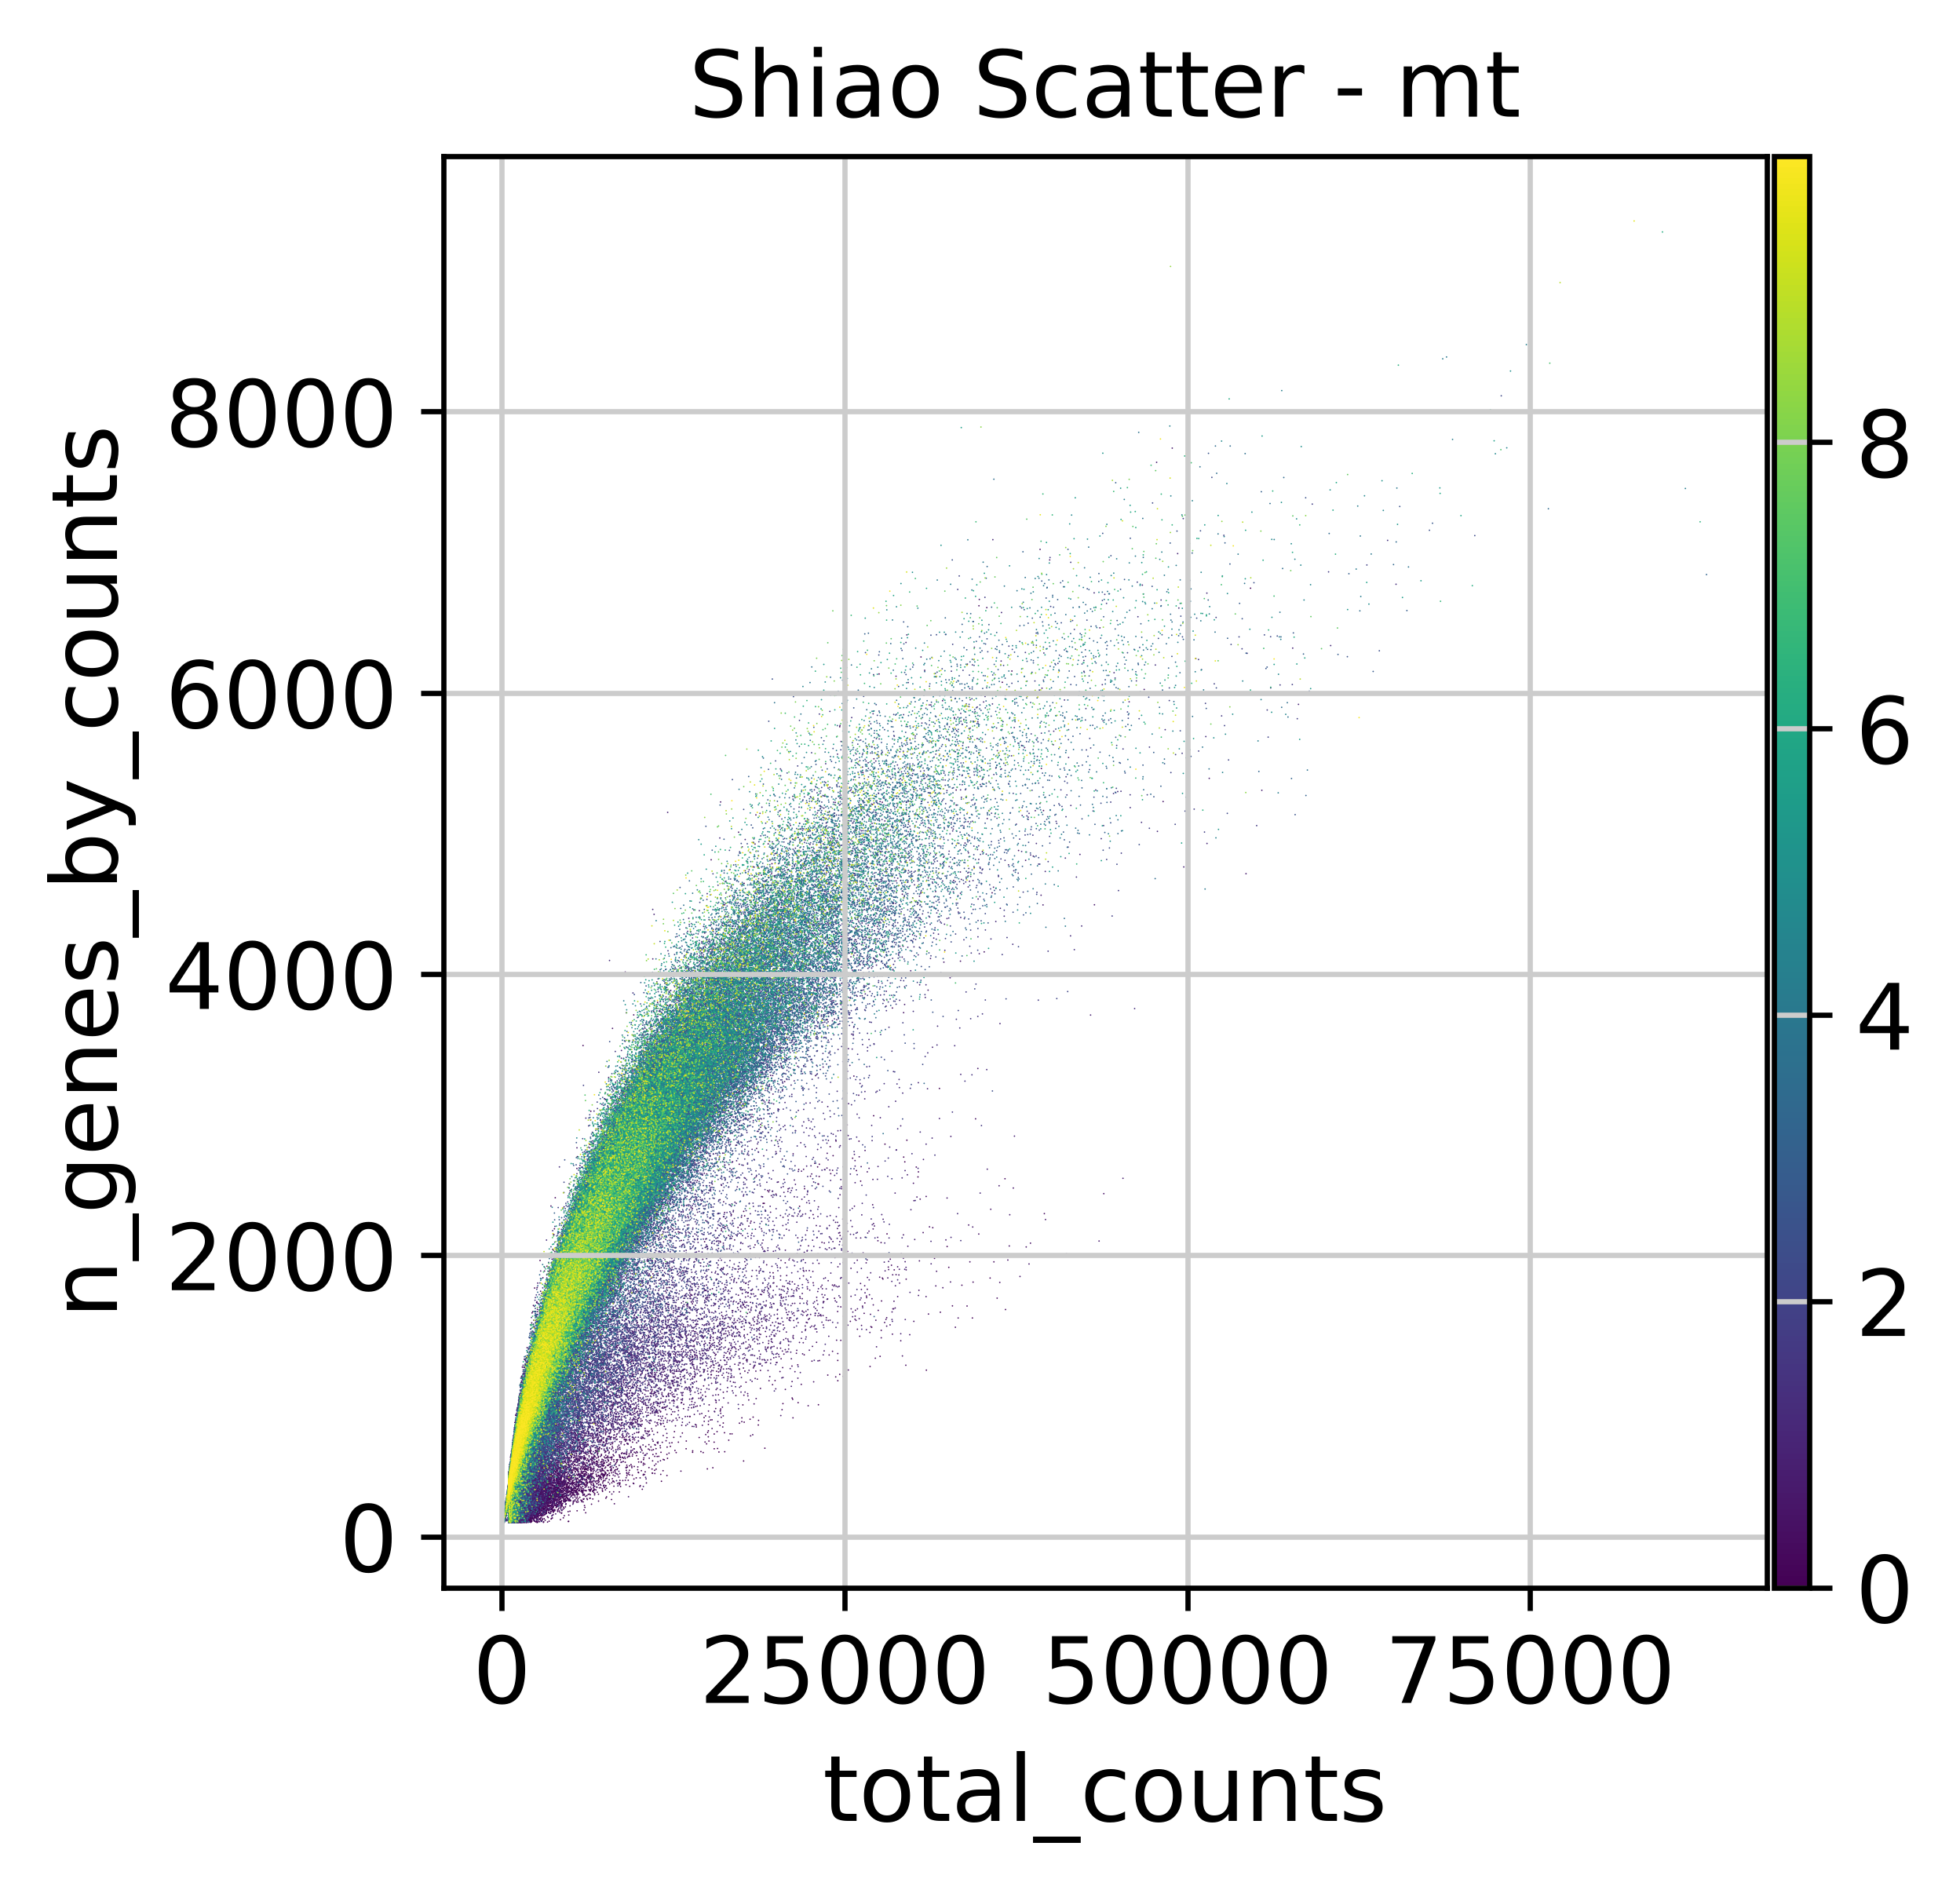

/tmp/ipykernel_17830/3948966146.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", color="dataset_origin", title= "Shiao Scatter - ds origin", save="_dataset_origin_total_counts_vs_n_genes_by_counts.png")


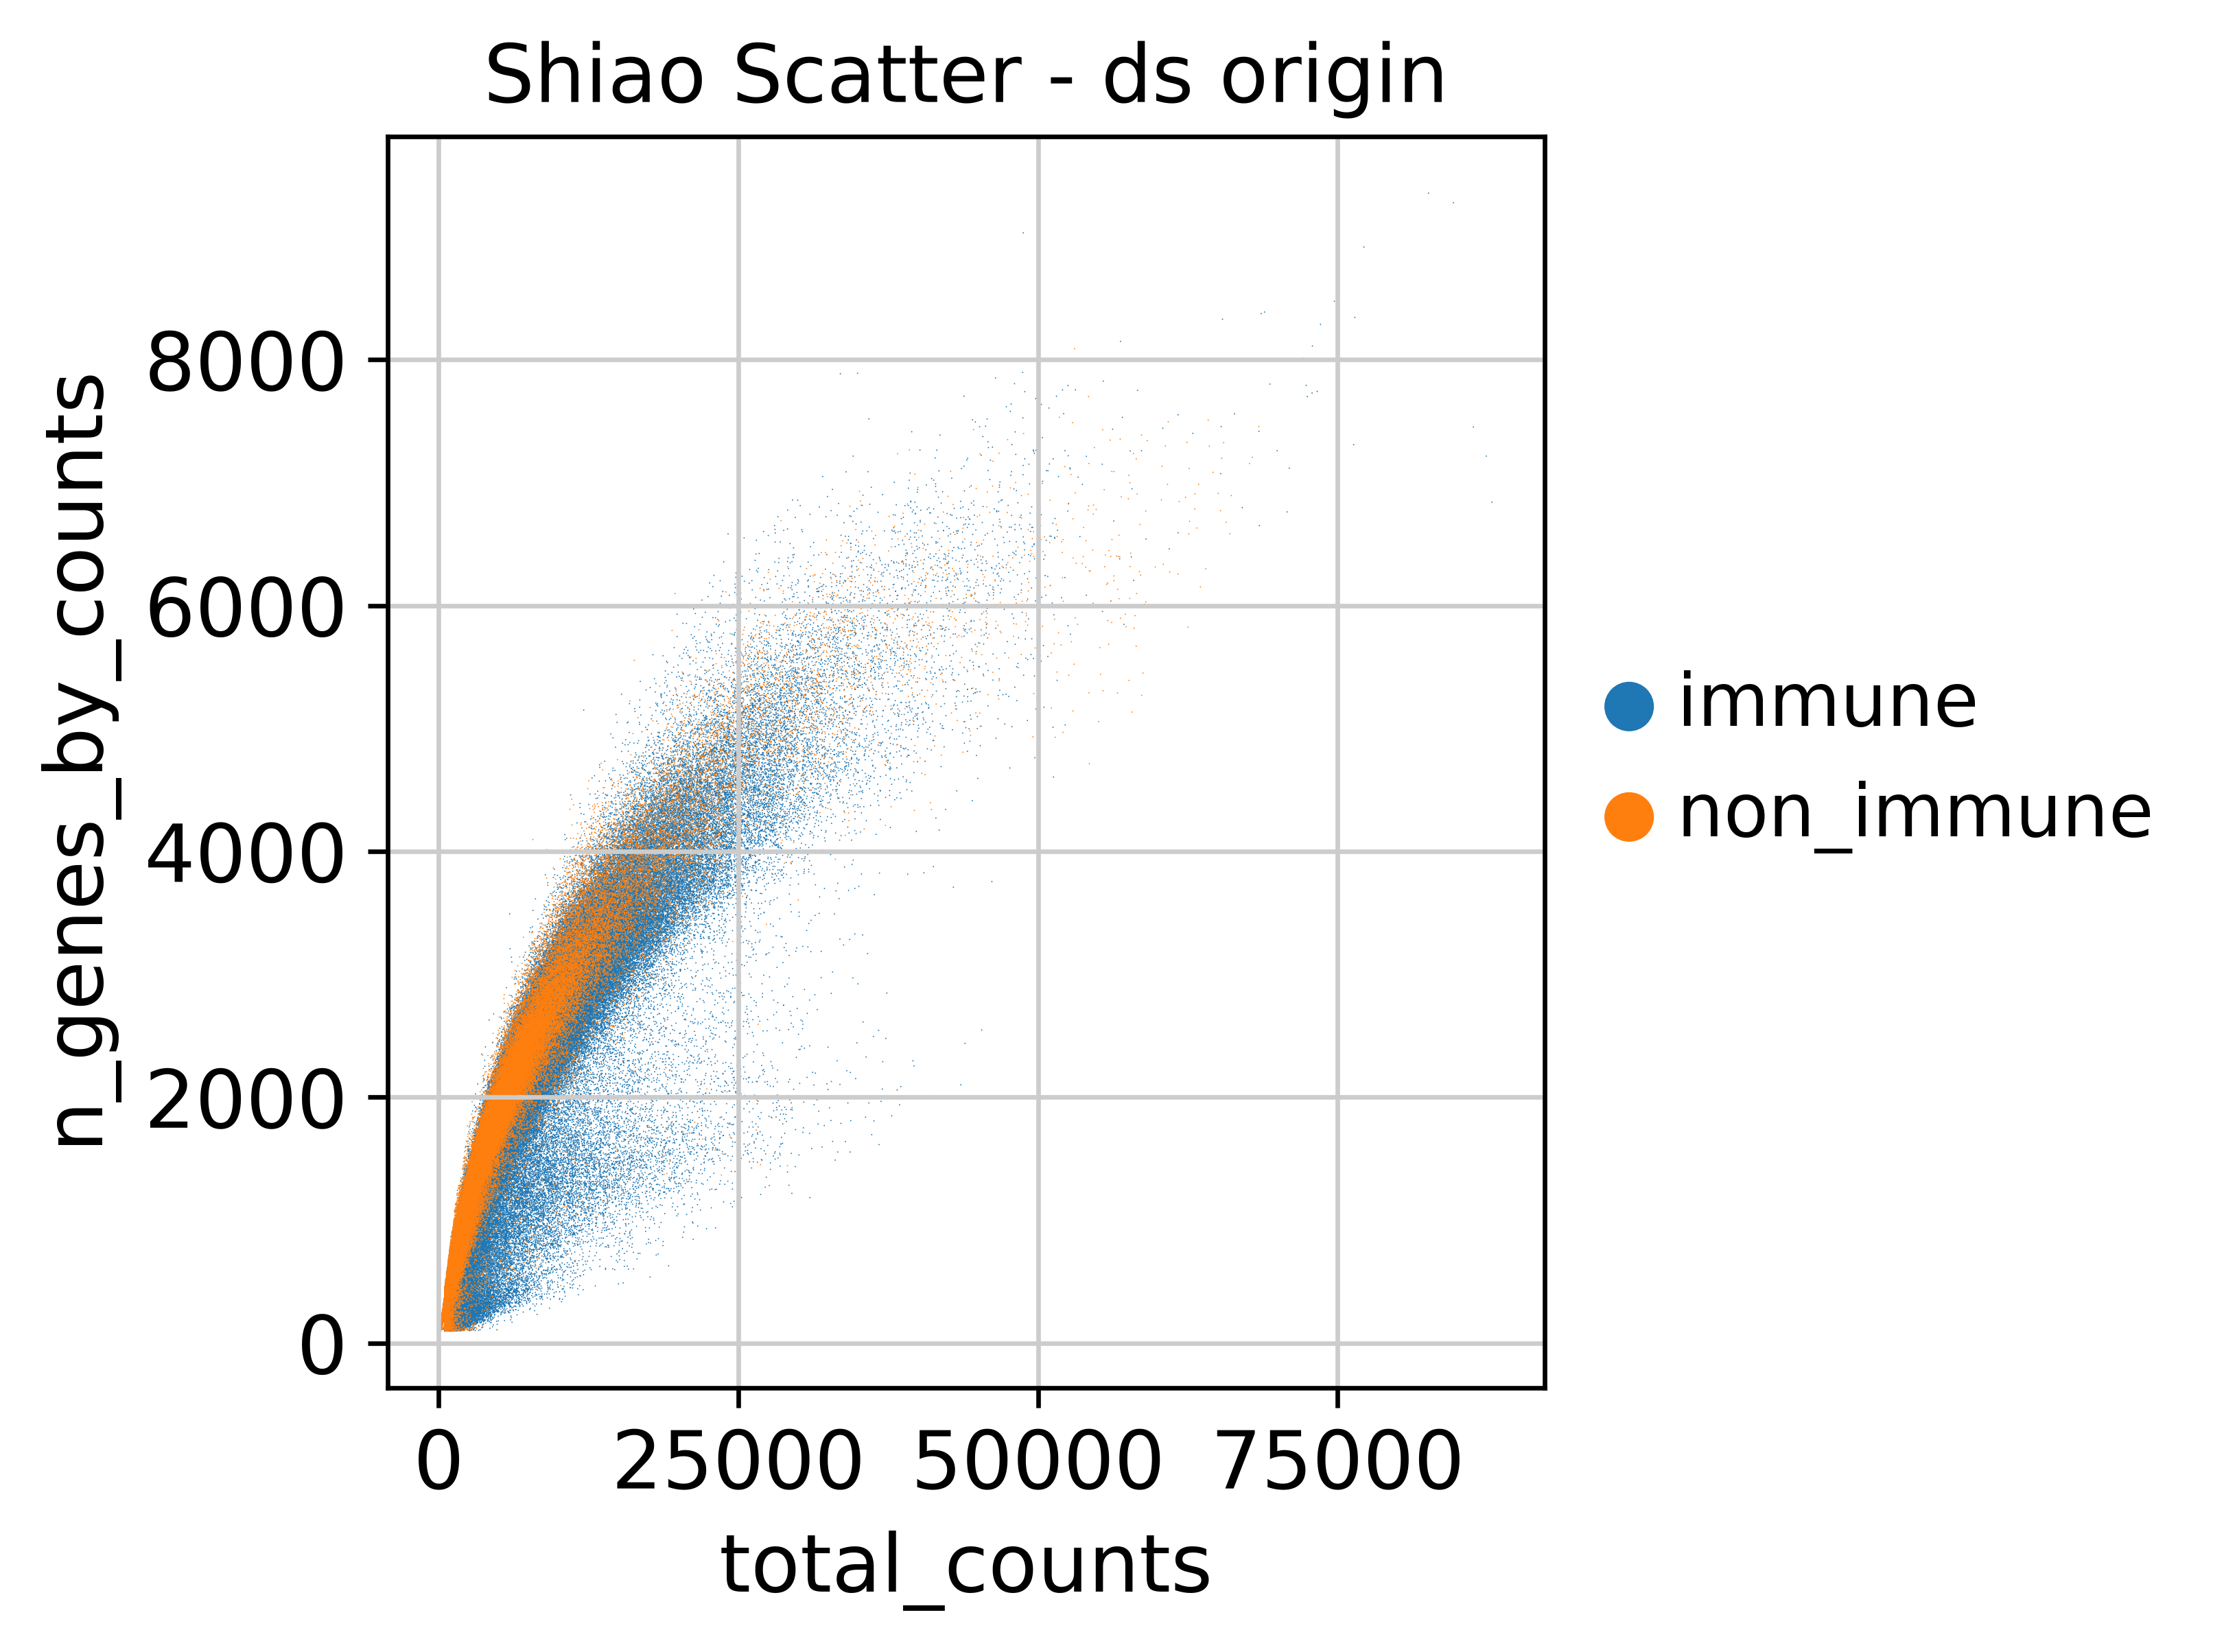

In [35]:
# Scatter plot of total_counts vs n_genes_by_counts color by percent_mito before qcnt_mito", title= "Original Shiao Scatter")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt", title= "Shiao Scatter - mt", save="_percent_mito_total_counts_vs_n_genes_by_counts.png")
# Scatter plot of totl_counts vs n_genes_by_counts color by origin 
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", color="dataset_origin", title= "Shiao Scatter - ds origin", save="_dataset_origin_total_counts_vs_n_genes_by_counts.png")